# Will this order come back failed?

A vendor either did or did not manage to synthesise a few dozen DNA constructs.
Nobody knows why. This is the notebook where that gets worked out — which is
where this kind of work has always lived, and, until recently, where it stopped.

The data here is synthetic. The real file is customer constructs under NDA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

df = pd.read_csv("data/orders.csv")
print(f"{len(df)} orders, {(df.synthesised == 'no').sum()} of them failed")
df.head()

44 orders, 20 of them failed


,sequence,purity,synthesised
0,ATGAGTAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTG...,yes,yes
1,GGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCG...,no,no
2,AAAGATGACGGGAACTACAAGACACGTGCTGAAGTCAAGTTTGAAG...,yes,yes
3,CAGGTCACCGGTAAAGGCTTTTCCAGGTCACCGGTAAAGGCTTTTC...,no,no
4,ATCAAAGTTAACTTCAAAATTAGACACAACATTGAAGATGGAAGCG...,yes,yes


## First, look at it

Three columns. The sequence the vendor was sent, whether the material came back
pure, and whether they managed to build it at all.

The obvious thing to try is to read the sequences and spot the difference.

In [2]:
fine = df.loc[df.synthesised == "yes", "sequence"].iloc[0]
failed = df.loc[df.synthesised == "no", "sequence"].iloc[0]

print("came back fine:")
print(" ", fine[:72])
print("\ncame back failed:")
print(" ", failed[:72])

came back fine:
  ATGAGTAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTT

came back failed:
  GGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCC


You can see it in that one, because it is the same six bases over and over.
Most of them are not that obvious, and forty of them are not something anyone
wants to eyeball.

## Twelve numbers instead

Every one of these is read off the string. Nothing here needed a lab, and
nothing here is new — these are the features the published analyses of synthesis
difficulty use.

In [3]:
from synthesis_check.features import features

X = features(df.sequence)
y = df.synthesised == "no"

X.head()

,longest_repeat,repeat_count,gc_content,max_window_gc,min_window_gc,tm,tm_spread,hairpin_stem,homopolymer_max,dinucleotide_repeat,length,fragments
0,4,2,36.4,40.0,36.0,69.6,12.8,5,4,4,66,2
1,36,7,100.0,100.0,100.0,96.6,4.2,36,2,4,72,2
2,5,2,38.1,48.0,32.0,72.5,4.1,5,4,4,84,3
3,23,2,66.7,70.0,56.0,82.0,3.1,10,4,4,66,2
4,6,2,34.4,42.0,32.0,71.6,5.1,6,4,4,90,3


## Does any single one of them separate the two groups?

In [4]:
comparison = pd.DataFrame({
    "came back fine": X[~y].mean(),
    "came back failed": X[y].mean(),
})
comparison["difference"] = comparison["came back failed"] - comparison["came back fine"]
comparison.sort_values("difference", key=abs, ascending=False).round(1)

,came back fine,came back failed,difference
max_window_gc,45.8,65.6,19.8
gc_content,39.8,56.6,16.8
min_window_gc,34.8,50.3,15.5
longest_repeat,8.0,22.0,14.0
length,101.5,88.9,-12.6
tm,74.2,80.3,6.1
dinucleotide_repeat,4.6,9.4,4.8
hairpin_stem,5.2,9.6,4.4
tm_spread,9.6,12.6,3.0
homopolymer_max,4.2,5.6,1.3


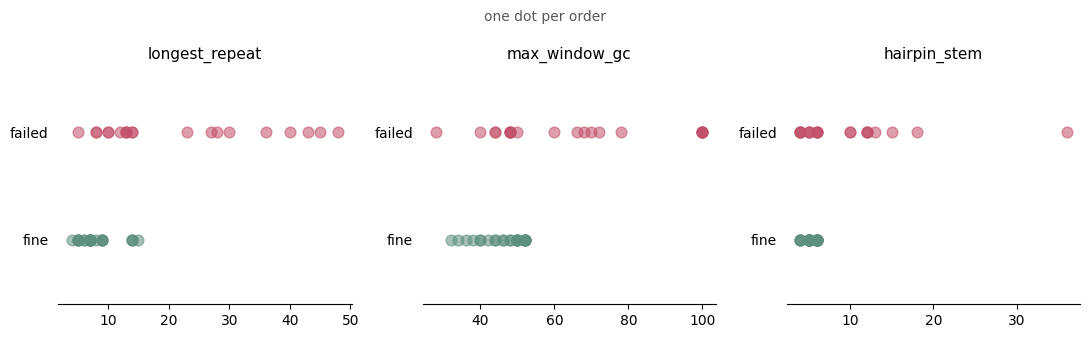

In [5]:
FINE, FAILED = "#5d8f7e", "#c2506a"

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, column in zip(axes, ["longest_repeat", "max_window_gc", "hairpin_stem"]):
    ax.scatter(X.loc[~y, column], [0] * (~y).sum(), s=60, alpha=0.55, color=FINE, label="fine")
    ax.scatter(X.loc[y, column], [1] * y.sum(), s=60, alpha=0.55, color=FAILED, label="failed")
    ax.set_yticks([0, 1], ["fine", "failed"])
    ax.set_ylim(-0.6, 1.6)
    ax.set_title(column, fontsize=11)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)

fig.suptitle("one dot per order", fontsize=10, color="#55595e")
fig.tight_layout()
plt.show()

The fine ones sit in a tight clump and the failures spread out to the right,
which is encouraging. But look at where they meet: there are failures with a
repeat of 8 and fine orders with a repeat of 15. Any single threshold you could
write down gets those wrong in both directions, which is the reason to fit
something instead of picking a number.

## Fit it

Leave-one-out rather than a held-out split, because a held-out split of a few
dozen rows tells you nothing: a 20% test set here is nine sequences, and the
score would swing ten points depending on which nine.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

clf = LogisticRegression(max_iter=1000)
score = cross_val_score(clf, X, y, cv=LeaveOneOut()).mean()

print(f"leave-one-out accuracy                   {score:.3f}")
print(f"always guessing the more common answer   {max(y.mean(), 1 - y.mean()):.3f}")

leave-one-out accuracy                   0.886
always guessing the more common answer   0.545


A smell test, not a p-value. Forty-four rows will not support anything
stronger, and saying so is part of the job.

## What is it actually using?

Interpretable on purpose. When it says no, a scientist has to be able to
disagree with the reason, and the reason has to be in units they already argue
in.

In [7]:
clf.fit(X, y)

weights = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
weights.head(6).round(3).to_frame("weight")

,weight
hairpin_stem,1.022
longest_repeat,0.679
homopolymer_max,0.647
dinucleotide_repeat,0.290
gc_content,0.290
min_window_gc,-0.225


Repeats, hairpins and homopolymer runs — the same three the literature ranks
highest, arrived at independently from forty-four rows of our own orders.

## Use it on something new

In [8]:
def check(sequence):
    from synthesis_check.features import COLUMNS, featurise

    row = featurise(sequence)
    risk = clf.predict_proba(pd.DataFrame([row], columns=COLUMNS))[0][1]
    failing = risk >= 0.5
    verdict = "likely to fail" if failing else "should be fine"
    confidence = risk if failing else 1 - risk
    print(f"{verdict}  ({confidence:.0%} confident)   repeat {row['longest_repeat']} bp, "
          f"GC {row['gc_content']:.0f}%, worst window {row['max_window_gc']:.0f}%")


check("ATGAGTAAAGGAGAAGAACTTTTCACTGGAGTTGTCCCAATTCTTGTTGAATTAGATGGTGATGTT")
check("GGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCCGGCGCC")

should be fine  (100% confident)   repeat 4 bp, GC 36%, worst window 40%
likely to fail  (100% confident)   repeat 33 bp, GC 100%, worst window 100%


## And this is where it used to stop

The analysis is done. It works. And it is completely useless to the scientist
who asked the question, because to get an answer out of it they would have to:

- install Python, pandas and scikit-learn,
- get a copy of this notebook and the data file,
- open Jupyter,
- run the cells **in order**,
- and edit the last one without breaking the ones above it.

So the traditional next step is to make it re-runnable by somebody else: wrap it
as a script, put it behind Nextflow or Snakemake or Galaxy, and hand that over.
Which is a genuine improvement, and still delivers a pipeline to a person who
already knows how to run pipelines.

The scientist wanted to know whether to reorder a construct.

That gap — between a notebook that works and an answer somebody can actually
get — is what the rest of the talk is about.